In [1]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')

import suffix_pred.evaluation
importlib.reload(suffix_pred.evaluation)
from suffix_pred.evaluation import DLSEvaluation, DLSConfig

import suffix_pred.models.K_UED_LSTM
importlib.reload(suffix_pred.models.K_UED_LSTM)
from suffix_pred.models.K_UED_LSTM import DropoutUncertaintyEncoderDecoderLSTM

In [2]:
# Model
file_path_model = '../../trainer/Helpdesk/Helpdesk_UED_LSTM_v1.pkl'
model = DropoutUncertaintyEncoderDecoderLSTM.load(file_path_model, dropout=0.1)

# Load the data
# Path to your pickle file (saved with torch.save)
file_path_test = '../../../../../data/Helpdesk/tensor_data/normal/helpdesk_all_5_test.pkl'
# Load the dataset using torch.load
test_dataset = torch.load(file_path_test, weights_only=False)

Dynamic data set categories:  ([('Activity', 15, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'INVALID': 5, 'Insert ticket': 6, 'RESOLVED': 7, 'Require upgrade': 8, 'Resolve SW anomaly': 9, 'Resolve ticket': 10, 'Schedule intervention': 11, 'Take in charge ticket': 12, 'VERIFIED': 13, 'Wait': 14}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Data set static categories:  ([('VariantIndex', 175, {'1': 1, '10': 2, '100': 3, '101': 4, '102': 5, '103': 6, '104': 7, '105': 8, '106': 9, '109': 10, '11': 11, '110': 12, '111': 13, '118': 1

In [3]:
# DLS Evaluation (probabilistic only)
config = DLSConfig(concept_name="Activity",
                   eos_value="EOS",
                   probabilistic_samples=100)

dls_eval = DLSEvaluation(model=model, dataset=test_dataset, config=config)

mode = "probabilistic"
prob_df = dls_eval.evaluate_probabilistic(random_order=False,
                                          num_processes = 32,
                                          reduction="mean")

prob_per_prefix = dls_eval.dls_per_prefix_length(prob_df)

prob_avg = dls_eval.average_dls(prob_df)

print(f"Average DLS ({mode}, mean over T samples): {prob_avg:.4f}")

  0%|          | 0/916 [00:00<?, ?it/s]

Average DLS (probabilistic, mean over T samples): 0.8382


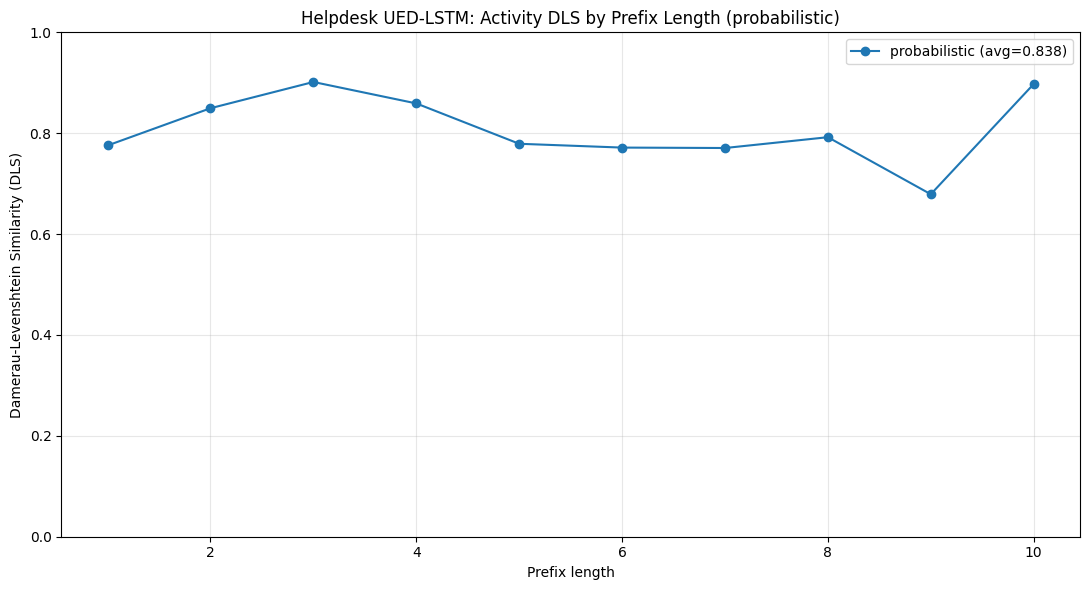

,mode,average_dls
0,probabilistic,0.838246


In [4]:
# ---------------------------
# One combined plot (single method requested: probabilistic only)
# ---------------------------
plt.figure(figsize=(11, 6))

plt.plot(
    prob_per_prefix["prefix_len"],
    prob_per_prefix["dls"],
    marker="o",
    label=f"probabilistic (avg={prob_avg:.3f})",
)

plt.title("Helpdesk UED-LSTM: Activity DLS by Prefix Length (probabilistic)")
plt.xlabel("Prefix length")
plt.ylabel("Damerau-Levenshtein Similarity (DLS)")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional summary table
summary = pd.DataFrame({
    "mode": [mode],
    "average_dls": [prob_avg],
}).sort_values("average_dls", ascending=False).reset_index(drop=True)
summary

In [ ]:
prob_df 